# **Customer Lifetime Value Prediction**
### AI for Communication and Marketing 

**Academic Year:** 2025/2026  
**Course:** B.Sc. in Artificial Intelligence  
**Student:** Irene Marrali                            

## Business Scenario

Olist is a major Brazilian e-commerce marketplace that connects customers, sellers and products through a non-contractual purchasing environment. Olist wants to **estimate the future value of its current customer base** to support budget allocation and loyalty campaigns.

This project compares a probabilistic BTYD approach, based on BG/NBD and Gamma-Gamma models, with a machine learning regression model.

The analysis will support two main business decisions:
1. **Financial planning:** estimating the total future value of the customer base and identifying the most reliable model for revenue forecasting.
2. **Operational marketing:** identifying customers with high predicted value but a low probability of remaining active, who should be prioritized in a targeted win-back campaign.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Data Loading

The analysis uses the main Olist relational tables containing information about **customers, orders, payments and order items.**

In [2]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
dataset_summary = pd.DataFrame({
    "Dataset": ["Customers", "Orders", "Payments", "Order Items"],
    "Rows": [
        customers.shape[0],
        orders.shape[0],
        payments.shape[0],
        order_items.shape[0]
    ],
    "Columns": [
        customers.shape[1],
        orders.shape[1],
        payments.shape[1],
        order_items.shape[1]
    ]
})

display(dataset_summary)

,Dataset,Rows,Columns
0,Customers,99441,5
1,Orders,99441,8
2,Payments,103886,5
3,Order Items,112650,7


In [4]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Payments": payments,
    "Order Items": order_items
}

for name, df in datasets.items():
    print(f"\n{name}")
    display(df.head())


Customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Payments


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



Order Items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


The preview confirms that each table contains a different type of information:
- The customers table contains customer identifiers and geographic attributes;
- The orders table contains order status and timestamps;
- The payments and order items tables **may contain multiple rows for the same order**, since one order can include multiple payment records or multiple products.

## Data Audit and Cleaning

Before building the transactional dataset, the original tables must be inspected to identify **structural differences, missing values, duplicate records and potential inconsistencies.** This step is important because the Olist dataset is **relational**: the same order may appear multiple times in the payments and order items tables. Therefore, the tables cannot be merged directly without first understanding their level of aggregation.

### Missing Values

Missing values are examined for each dataset and variable. Their interpretation depends on the meaning of the column: some missing values may indicate data quality problems, while others may result from incomplete or cancelled orders.

In [5]:
# Create an empty list to store missing-value information.
missing_records = []

# Analyse every column in every dataset.
for dataset_name, dataframe in datasets.items():
    
    for column_name in dataframe.columns:
        
        # Count the number of missing values in the current column.
        missing_count = dataframe[column_name].isna().sum()
        
        # Calculate the percentage of missing values.
        missing_percentage = (
            missing_count / len(dataframe) * 100
        )
        
        # Store the results.
        missing_records.append({
            "Dataset": dataset_name,
            "Column": column_name,
            "Missing Values": missing_count,
            "Missing Percentage": missing_percentage
        })

# Convert the results into a DataFrame.
missing_summary = pd.DataFrame(missing_records)

# Keep only columns containing at least one missing value.
missing_summary_with_values = (
    missing_summary[missing_summary["Missing Values"] > 0]
    .sort_values(
        by=["Dataset", "Missing Percentage"],
        ascending=[True, False]
    )
)

# Display the final summary.
display(missing_summary_with_values)

,Dataset,Column,Missing Values,Missing Percentage
11,Orders,order_delivered_customer_date,2965,2.98
10,Orders,order_delivered_carrier_date,1783,1.79
9,Orders,order_approved_at,160,0.16


The missing values are limited to order-related timestamps. In particular, delivery dates are missing **for a small percentage of orders**, which may be associated with cancelled, unavailable or incomplete transactions. These rows will not be removed solely because they contain missing values. Instead, missing timestamps will be interpreted together with `order_status`. Since CLTV must be based on valid completed purchases, only delivered orders will be retained during the cleaning stage.

### Duplicate Records

Duplicate records are examined before aggregation because they may artificially increase purchase frequency, quantities or customer spending.

**Complete duplicate rows are distinguished from repeated identifiers**. In relational tables such as payments and order items, the same `order_id` may legitimately appear multiple times.


In [6]:
# Create an empty list to store duplicate information.
duplicate_records = []

# Check complete duplicate rows in each dataset.
for dataset_name, dataframe in datasets.items():
    
    # Count rows that are exact duplicates across all columns.
    duplicate_count = dataframe.duplicated().sum()
    
    # Calculate the percentage of duplicate rows.
    duplicate_percentage = (
        duplicate_count / len(dataframe) * 100
    )
    
    # Store the results for the current dataset.
    duplicate_records.append({
        "Dataset": dataset_name,
        "Total Rows": len(dataframe),
        "Complete Duplicate Rows": duplicate_count,
        "Duplicate Percentage": duplicate_percentage
    })

# Convert the collected results into a summary DataFrame.
duplicate_summary = pd.DataFrame(duplicate_records)

# Display the duplicate analysis.
display(duplicate_summary)

,Dataset,Total Rows,Complete Duplicate Rows,Duplicate Percentage
0,Customers,99441,0,0.00
1,Orders,99441,0,0.00
2,Payments,103886,0,0.00
3,Order Items,112650,0,0.00


No complete duplicate rows were found in any of the four datasets. Therefore, no records need to be removed at this stage. However, repeated identifiers such as `order_id` in the payments and order items tables will be analysed separately, since they may represent **valid one-to-many relationships** rather than duplicate records.

### Data Anomalies

Potential anomalies are investigated before defining the cleaning pipeline. The analysis focuses on:

1. **Order Status Distribution**: to distinguish completed purchases from cancelled, unavailable or incomplete transactions.
2. **Invalid Monetary Values**: prices, freight costs and payment values are checked for zero or negative values. Negative values would be inconsistent with normal purchase transactions.
3. **Number of Items per Order**: the order items table does not contain an explicit quantity variable. Therefore, the number of items in each order is calculated by counting the item records associated with each `order_id`.
4. **Order Value Distribution**: payment records are aggregated at order level to calculate the total amount paid for each order. This prevents orders with multiple payment records from being counted more than once.

In [7]:
# Count the number of orders associated with each status.
order_status_summary = (
    orders["order_status"]
    .value_counts(dropna=False)
    .rename_axis("Order Status")
    .reset_index(name="Number of Orders")
)

# Calculate the percentage of orders represented by each status.
order_status_summary["Percentage"] = (
    order_status_summary["Number of Orders"]
    / len(orders)
    * 100
)

# Display the order-status distribution.
display(order_status_summary)

,Order Status,Number of Orders,Percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


Delivered orders represent 97.02% of the dataset, while the remaining records correspond to cancelled, unavailable or incomplete transactions. Since CLTV must be calculated using valid completed purchases, **only orders with status `delivered` will be retained during the cleaning phase**. Orders with other statuses will be excluded because they do not represent confirmed customer revenue.

In [8]:
# Aggregate payment records at order level.
order_payment_totals = (
    payments.groupby("order_id", as_index=False)
    .agg(
        Total_Payment_Value=("payment_value", "sum")
    )
)

# Create a summary of invalid or unusual monetary values.
monetary_anomalies = pd.DataFrame({
    "Variable": [
        "price",
        "freight_value",
        "total_order_payment"
    ],
    "Missing Values": [
        order_items["price"].isna().sum(),
        order_items["freight_value"].isna().sum(),
        order_payment_totals["Total_Payment_Value"].isna().sum()
    ],
    "Zero Values": [
        (order_items["price"] == 0).sum(),
        (order_items["freight_value"] == 0).sum(),
        (order_payment_totals["Total_Payment_Value"] == 0).sum()
    ],
    "Negative Values": [
        (order_items["price"] < 0).sum(),
        (order_items["freight_value"] < 0).sum(),
        (order_payment_totals["Total_Payment_Value"] < 0).sum()
    ]
})

# Display the corrected monetary anomaly summary.
display(monetary_anomalies)

,Variable,Missing Values,Zero Values,Negative Values
0,price,0,0,0
1,freight_value,0,383,0
2,total_order_payment,0,3,0


The **383 zero freight values** are not necessarily anomalous, since they may represent free-shipping transactions and will therefore be retained.

After aggregating payment records at order level, **only three orders** have a total payment value equal to zero. If they correspond to delivered orders with a total order payment equal to zero, they will be treated as invalid transactions and excluded from the CLTV analysis.

In [9]:
# Aggregate all payment records at order level.
order_payment_totals = (
    payments.groupby("order_id", as_index=False)
    .agg(
        Total_Payment_Value=("payment_value", "sum"),
        Number_of_Payment_Records=("payment_sequential", "count")
    )
)

# Keep only orders whose total payment value is exactly zero.
zero_total_payment_orders = order_payment_totals[
    order_payment_totals["Total_Payment_Value"] == 0
].copy()

# Add order status and purchase timestamp for interpretation.
zero_total_payment_analysis = zero_total_payment_orders.merge(
    orders[
        [
            "order_id",
            "order_status",
            "order_purchase_timestamp"
        ]
    ],
    on="order_id",
    how="left"
)

# Display only orders with total payment equal to zero.
display(zero_total_payment_analysis)

,order_id,Total_Payment_Value,Number_of_Payment_Records,order_status,order_purchase_timestamp
0,00b1cb0320190ca0daa2c88b35206009,0.00,1,canceled,2018-08-28 15:26:39
1,4637ca194b6387e2d538dc89b124b0ee,0.00,1,canceled,2018-09-03 14:14:25
2,c8c528189310eaa44a745b8d9d26908b,0.00,1,canceled,2018-08-28 20:05:14


All three orders are marked as `cancelled`, so they do not represent valid completed transactions. They will therefore be removed during the cleaning phase together with the other non-delivered orders.

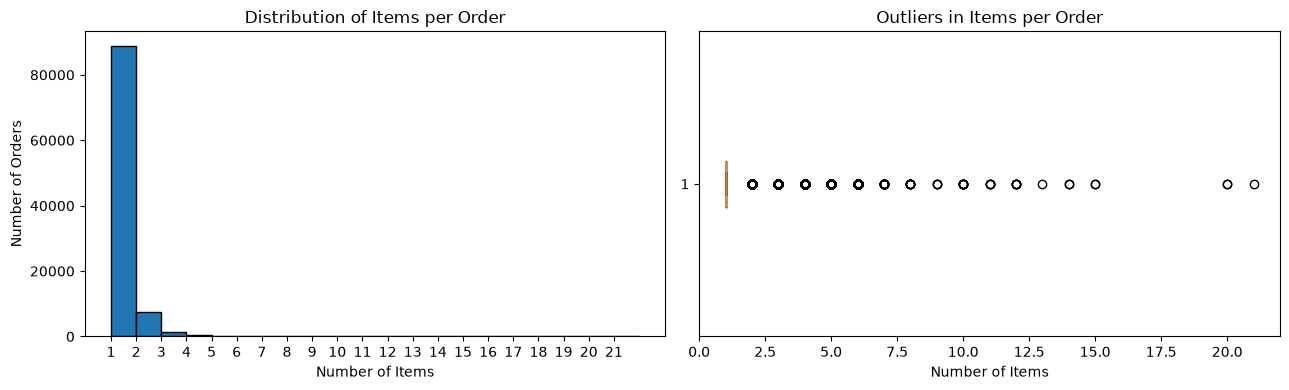

,Q1,Q3,IQR,Upper Bound,Potential Outlier Orders,Potential Outlier Percentage
0,1.00,1.00,0.00,1.00,9803,9.94


,order_id,Number of Items
50137,8272b63d03f5f79c56e9e4120aec44ef,21
10459,1b15974a0141d54e36626dca3fdc731a,20
65715,ab14fdcfbe524636d65ee38360e22ce8,20
60941,9ef13efd6949e4573a18964dd1bbe7f5,15
25583,428a2f660dc84138d969ccd69a0ab6d5,15
59688,9bdc4d4c71aa1de4606060929dee888c,14
44594,73c8ab38f07dc94389065f7eba4f297a,14
21484,37ee401157a3a0b28c9c6d0ed8c3b24b,13
67424,af822dacd6f5cff7376413c03a388bb7,12
22378,3a213fcdfe7d98be74ea0dc05a8b31ae,12


In [10]:
# Import the plotting library.
import matplotlib.pyplot as plt

# Count the number of item records associated with each order.
# Each row in the order items table represents one item within an order.
items_per_order = (
    order_items.groupby("order_id")
    .size()
    .reset_index(name="Number of Items")
)

# Calculate the quartiles of the item-count distribution.
q1_items = items_per_order["Number of Items"].quantile(0.25)
q3_items = items_per_order["Number of Items"].quantile(0.75)

# Calculate the Interquartile Range (IQR).
iqr_items = q3_items - q1_items

# Define the conventional IQR upper threshold for potential outliers.
upper_bound_items = q3_items + 1.5 * iqr_items

# Identify orders whose number of items exceeds the IQR threshold.
item_outliers = items_per_order[
    items_per_order["Number of Items"] > upper_bound_items
].copy()

# Create one figure containing the distribution and the boxplot.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot the frequency distribution of items per order.
axes[0].hist(
    items_per_order["Number of Items"],
    bins=range(
        1,
        int(items_per_order["Number of Items"].max()) + 2
    ),
    edgecolor="black"
)

axes[0].set_title("Distribution of Items per Order")
axes[0].set_xlabel("Number of Items")
axes[0].set_ylabel("Number of Orders")
axes[0].set_xticks(
    range(
        1,
        int(items_per_order["Number of Items"].max()) + 1
    )
)

# Plot the boxplot to highlight potential extreme values.
axes[1].boxplot(
    items_per_order["Number of Items"],
    vert=False
)

axes[1].set_title("Outliers in Items per Order")
axes[1].set_xlabel("Number of Items")

# Improve spacing between the two plots.
plt.tight_layout()

# Display the final figure.
plt.show()

# Summarize the IQR threshold and the identified potential outliers.
item_outlier_summary = pd.DataFrame({
    "Q1": [q1_items],
    "Q3": [q3_items],
    "IQR": [iqr_items],
    "Upper Bound": [upper_bound_items],
    "Potential Outlier Orders": [len(item_outliers)],
    "Potential Outlier Percentage": [
        len(item_outliers) / len(items_per_order) * 100
    ]
})

# Display the numerical outlier summary.
display(item_outlier_summary)

# Display the largest observed item counts.
display(
    items_per_order
    .sort_values("Number of Items", ascending=False)
    .head(15)
)

The distribution is strongly concentrated at one item per order, while only a small number of orders contain very high quantities. The IQR method is not fully appropriate because Q1 and Q3 are both equal to 1, causing all multi-item orders to be classified as potential outliers. **Since orders with 20 or 21 items are still plausible purchases, no quantity-based observations are removed.**

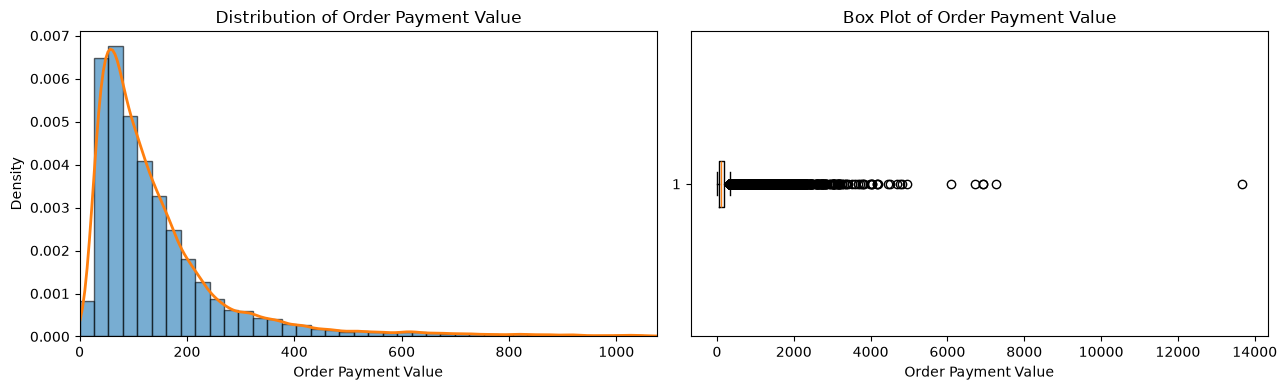

In [11]:
# Extract total payment values at order level.
payment_values = order_payment_totals["Total_Payment_Value"]

# Calculate the 99th percentile for a clearer visualization.
payment_value_p99 = payment_values.quantile(0.99)

# Keep values up to the 99th percentile only for the distribution plot.
# No observations are removed from the dataset.
payment_values_for_plot = payment_values[
    payment_values <= payment_value_p99
]

# Create a figure with the distribution and the boxplot.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot the distribution up to the 99th percentile.
axes[0].hist(
    payment_values_for_plot,
    bins=40,
    density=True,
    edgecolor="black",
    alpha=0.6
)

# Add the KDE curve without extending beyond the observed range.
payment_values_for_plot.plot(
    kind="kde",
    ax=axes[0],
    linewidth=2,
    ind=500
)
# Restrict the x-axis to valid and visible payment values.
axes[0].set_xlim(0, payment_value_p99)

axes[0].set_title("Distribution of Order Payment Value")
axes[0].set_xlabel("Order Payment Value")
axes[0].set_ylabel("Density")

# Plot the complete dataset in the boxplot.
axes[1].boxplot(
    payment_values,
    vert=False
)

axes[1].set_title("Box Plot of Order Payment Value")
axes[1].set_xlabel("Order Payment Value")

# Improve spacing between plots.
plt.tight_layout()

# Display the final figure.
plt.show()

Order payment values are **strongly right-skewed**, with most transactions concentrated at low and moderate values and a small number of very expensive orders.

Although the boxplot identifies several statistical outliers, high-value purchases are plausible in an e-commerce context and are not automatically considered data errors. Therefore, valid completed orders will be retained, while a logarithmic transformation may be applied during machine learning modeling to reduce the influence of extreme values.

## Data Cleaning and Preprocessing Pipeline

A reproducible cleaning pipeline is developed to **transform the original relational tables into a valid transactional dataset for CLTV analysis.**

The pipeline:

- **converts timestamp variables into datetime format**, because temporal features and the calibration–holdout split require correctly formatted dates;
- **retains only completed transactions**, because CLTV must be based on confirmed purchases rather than cancelled or incomplete orders;
- **removes orders with non-positive total payment values**, because they do not represent valid revenue-generating transactions;
- **aggregates payments and items at order level**, because the same order may appear multiple times in these relational tables;
- **merges customer, order, payment and item information**, creating a complete view of each transaction;
- **returns one row per valid order**, preventing duplicate revenue and ensuring consistency for customer-level aggregation.

In [12]:
def build_clean_transactional_dataset(
    customers_df,
    orders_df,
    payments_df,
    order_items_df
):

    # Create copies to preserve the original datasets.
    customers_clean = customers_df.copy()
    orders_clean = orders_df.copy()
    payments_clean = payments_df.copy()
    items_clean = order_items_df.copy()

    # Store the original number of orders.
    original_orders = len(orders_clean)

    # Convert order timestamp columns to datetime format.
    date_columns = [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]

    for column in date_columns:
        orders_clean[column] = pd.to_datetime(
            orders_clean[column],
            errors="coerce"
        )

    # Retain only completed delivered orders.
    orders_clean = orders_clean[
        orders_clean["order_status"] == "delivered"
    ].copy()

    # Remove orders without a valid purchase timestamp.
    orders_clean = orders_clean[
        orders_clean["order_purchase_timestamp"].notna()
    ].copy()

    delivered_orders = len(orders_clean)

    # Aggregate payment records at order level.
    payments_aggregated = (
        payments_clean.groupby("order_id", as_index=False)
        .agg(
            order_payment_value=("payment_value", "sum"),
            number_of_payment_records=("payment_sequential", "count"),
            maximum_installments=("payment_installments", "max"),
            number_of_payment_methods=("payment_type", "nunique")
        )
    )

    # Retain only orders with a positive total payment value.
    payments_aggregated = payments_aggregated[
        payments_aggregated["order_payment_value"] > 0
    ].copy()

    # Aggregate item-level records at order level.
    items_aggregated = (
        items_clean.groupby("order_id", as_index=False)
        .agg(
            number_of_items=("order_item_id", "count"),
            total_item_value=("price", "sum"),
            total_freight_value=("freight_value", "sum"),
            number_of_products=("product_id", "nunique"),
            number_of_sellers=("seller_id", "nunique")
        )
    )

    # Create the total item value including freight.
    items_aggregated["item_and_freight_value"] = (
        items_aggregated["total_item_value"]
        + items_aggregated["total_freight_value"]
    )

    # Merge valid orders with customer information.
    transactions_df = orders_clean.merge(
        customers_clean[
            [
                "customer_id",
                "customer_unique_id",
                "customer_zip_code_prefix",
                "customer_city",
                "customer_state"
            ]
        ],
        on="customer_id",
        how="inner"
    )

    # Merge payment information.
    transactions_df = transactions_df.merge(
        payments_aggregated,
        on="order_id",
        how="inner"
    )

    # Merge item information.
    transactions_df = transactions_df.merge(
        items_aggregated,
        on="order_id",
        how="inner"
    )

    # Sort transactions chronologically.
    transactions_df = transactions_df.sort_values(
        by="order_purchase_timestamp"
    ).reset_index(drop=True)

    # Create a summary of the cleaning process.
    cleaning_summary = pd.DataFrame({
        "Stage": [
            "Original orders",
            "Delivered orders with valid purchase date",
            "Final valid transactional records"
        ],
        "Number of Records": [
            original_orders,
            delivered_orders,
            len(transactions_df)
        ]
    })

    return transactions_df, cleaning_summary

In [13]:
# Run the complete cleaning and preprocessing pipeline.
transactions, cleaning_summary = build_clean_transactional_dataset(
    customers,
    orders,
    payments,
    order_items
)

# Display the cleaning summary.
display(cleaning_summary)

# Display the final transactional dataset.
print("Final transactional dataset shape:", transactions.shape)
display(transactions.head())

,Stage,Number of Records
0,Original orders,99441
1,Delivered orders with valid purchase date,96478
2,Final valid transactional records,96477


Final transactional dataset shape: (96477, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_payment_value,number_of_payment_records,maximum_installments,number_of_payment_methods,number_of_items,total_item_value,total_freight_value,number_of_products,number_of_sellers,item_and_freight_value
0,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,32ea3bdedab835c3aa6cb68ce66565ef,4106,sao paulo,SP,45.46,1,1,1,1,29.90,15.56,1,1,45.46
1,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,2f64e403852e6893ae37485d5fcacdaf,98280,panambi,RS,39.09,1,1,1,1,21.90,17.19,1,1,39.09
2,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,61db744d2f835035a5625b59350c6b63,90040,porto alegre,RS,53.73,1,1,1,1,36.49,17.24,1,1,53.73
3,d207cc272675637bfed0062edffd0818,b8cf418e97ae795672d326288dfab7a7,delivered,2016-10-03 22:06:03,2016-10-04 10:28:07,2016-10-21 14:23:37,2016-10-31 11:07:42,2016-11-23,8d3a54507421dbd2ce0a1d58046826e0,13185,hortolandia,SP,133.46,1,6,1,1,119.90,13.56,1,1,133.46
4,cd3b8574c82b42fc8129f6d502690c3e,7812fcebfc5e8065d31e1bb5f0017dae,delivered,2016-10-03 22:31:31,2016-10-04 10:19:23,2016-10-08 10:34:01,2016-10-14 16:08:00,2016-11-23,87776adb449c551e74c13fc34f036105,12030,taubate,SP,40.95,1,4,1,1,29.99,10.96,1,1,40.95


The cleaning pipeline reduced the dataset from **99,441 original orders to 96,477 valid transactional records.** Most excluded observations correspond to non-delivered orders, while one additional record was removed because it did not satisfy the final payment or merge requirements. The resulting dataset contains one row per valid completed order and is ready for exploratory analysis and customer-level feature engineering.

## Exploratory Data Analysis (EDA)

This section transforms the cleaned transactional dataset into a **customer-level table** containing Recency, Frequency, Monetary Value and customer tenure (`T`). The distributions of purchase frequency, recency and customer spend are then analysed to identify relevant patterns in customer retention.

### RFM Feature Engineering

The transactional dataset contains one row per valid completed order. It is therefore **aggregated at customer level** to summarize individual purchasing behaviour.

The following variables are created:

- **Recency:** number of days since the customer's most recent purchase;
- **Frequency:** number of completed orders placed by the customer;
- **Monetary Value:** total amount spent by the customer;
- **T:** number of days between the customer's first purchase and the reference date.

In [14]:
# Define the reference date as one day after the last observed purchase.
# This ensures that customers who purchased on the final date have a recency of one day.
reference_date = (
    transactions["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

# Aggregate the transactional dataset at customer level.
rfm_table = (
    transactions
    .groupby("customer_unique_id")
    .agg(
        # Store the first observed purchase date for each customer.
        first_purchase_date=("order_purchase_timestamp", "min"),
        
        # Store the most recent purchase date for each customer.
        last_purchase_date=("order_purchase_timestamp", "max"),
        
        # Count the number of completed orders placed by each customer.
        Frequency=("order_id", "nunique"),
        
        # Calculate the total amount spent by each customer.
        Monetary_Value=("order_payment_value", "sum")
    )
    .reset_index()
)

# Calculate Recency as the number of days between
# the reference date and the customer's last purchase.
rfm_table["Recency"] = (
    reference_date
    - rfm_table["last_purchase_date"]
).dt.days

# Calculate customer tenure T as the number of days between
# the reference date and the customer's first purchase.
rfm_table["T"] = (
    reference_date
    - rfm_table["first_purchase_date"]
).dt.days

# Keep only the variables required for the customer-level RFM table.
rfm_table = rfm_table[
    [
        "customer_unique_id",
        "Recency",
        "Frequency",
        "Monetary_Value",
        "T"
    ]
]

# Display the first rows of the final customer-level table.
display(rfm_table.head())

# Display the dimensions of the customer-level dataset.
print("Customer-level table shape:", rfm_table.shape)

,customer_unique_id,Recency,Frequency,Monetary_Value,T
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,112
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,115
2,0000f46a3911fa3c0805444483337064,537,1,86.22,537
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,321
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,288


Customer-level table shape: (93357, 5)


The customer-level table contains **93,357 unique customers.**

For one-time customers, Recency and `T` are equal because the first and last purchase dates coincide. This already suggests that a **large share of the customer base may consist of single-purchase customers**, which will be investigated in the retention analysis.

### Distribution of Frequency, Recency and Customer Spend

The distributions of purchase frequency, recency and monetary value are analysed together to provide a complete view of customer behaviour.

Frequency measures repeat purchasing, Recency indicates how recently customers purchased, and Monetary Value represents total customer spending.

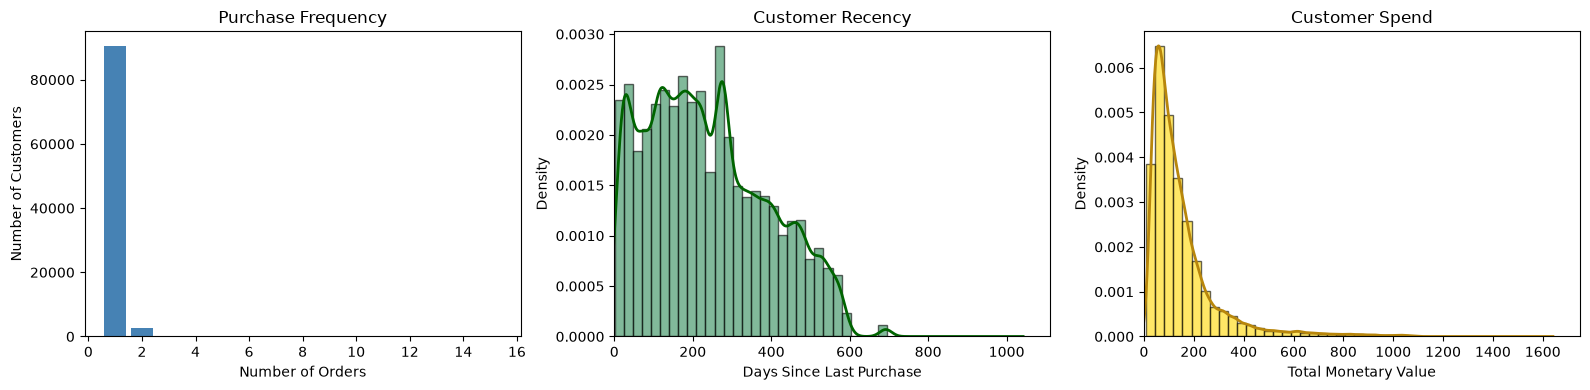

In [15]:
# Create a figure containing the three distributions required by the task.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Purchase Frequency
# Count how many customers belong to each frequency value.
frequency_counts = (
    rfm_table["Frequency"]
    .value_counts()
    .sort_index()
)

# Plot the discrete frequency distribution.
axes[0].bar(
    frequency_counts.index,
    frequency_counts.values,
    color="steelblue"
)

axes[0].set_title("Purchase Frequency")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Number of Customers")

# 2. Customer Recency
# Plot the recency histogram using density values
# so that the KDE curve can be displayed on the same scale.
axes[1].hist(
    rfm_table["Recency"],
    bins=30,
    density=True,
    edgecolor="black",
    alpha=0.6,
    color="seagreen"
)

# Add the KDE curve to show the overall distribution shape.
rfm_table["Recency"].plot(
    kind="kde",
    ax=axes[1],
    linewidth=2,
    color="darkgreen"
)

axes[1].set_title("Customer Recency")
axes[1].set_xlabel("Days Since Last Purchase")
axes[1].set_ylabel("Density")
axes[1].set_xlim(left=0)


# 3. Customer Spend
# Calculate the 99th percentile for visualization only.
monetary_p99 = rfm_table["Monetary_Value"].quantile(0.99)

# Keep values up to the 99th percentile only for plotting.
# No customers are removed from the dataset.
monetary_values_for_plot = rfm_table.loc[
    rfm_table["Monetary_Value"] <= monetary_p99,
    "Monetary_Value"
]

# Plot the customer-spend histogram.
axes[2].hist(
    monetary_values_for_plot,
    bins=30,
    density=True,
    edgecolor="black",
    alpha=0.6,
    color="gold"
)

# Add the KDE curve.
monetary_values_for_plot.plot(
    kind="kde",
    ax=axes[2],
    linewidth=2,
    color="darkgoldenrod"
)

axes[2].set_title("Customer Spend")
axes[2].set_xlabel("Total Monetary Value")
axes[2].set_ylabel("Density")
axes[2].set_xlim(left=0)

# Improve spacing between the three plots.
plt.tight_layout()

# Display the final figure.
plt.show()

1. **Purchase frequency** is highly concentrated at one order, showing that most customers purchased only once. This indicates weak repeat-purchase behaviour and limited customer retention.

2. **Recency** is widely distributed, with many customers whose last purchase occurred several months before the reference date. This suggests that a substantial part of the customer base has become inactive over time.

3. **Customer spend** is strongly right-skewed: most customers generated relatively low monetary value, while a small group contributed substantially higher spending. Overall, the results highlight the need for **retention and win-back initiatives**, especially for valuable customers who have not purchased recently.

In [16]:
# Count customers who purchased only once.
one_time_customers = (
    rfm_table["Frequency"] == 1
).sum()

# Count customers who made more than one purchase.
repeat_customers = (
    rfm_table["Frequency"] > 1
).sum()

# Calculate the corresponding percentages.
one_time_percentage = (
    one_time_customers / len(rfm_table) * 100
)

repeat_percentage = (
    repeat_customers / len(rfm_table) * 100
)

# Create a concise customer-retention summary.
retention_summary = pd.DataFrame({
    "Customer Group": [
        "One-Time Customers",
        "Repeat Customers"
    ],
    "Number of Customers": [
        one_time_customers,
        repeat_customers
    ],
    "Percentage": [
        one_time_percentage,
        repeat_percentage
    ]
})

# Display the retention results.
display(retention_summary)

,Customer Group,Number of Customers,Percentage
0,One-Time Customers,90556,97.00
1,Repeat Customers,2801,3.00


The retention summary confirms that Olist's customer base is overwhelmingly composed of **one-time buyers.** Approximately **97% of customers placed only one order**, while only **3% made repeat purchases**. This indicates very weak customer retention and suggests that loyalty and win-back campaigns should focus on converting first-time buyers into returning customers.

## Modeling and Evaluation

This section develops and compares two approaches for predicting future customer value.

1. The first approach is a **probabilistic BTYD framework** based on the **BG/NBD and Gamma-Gamma models**. It is used to estimate the expected number of future purchases, the probability that a customer is still active and the predicted 90-day CLTV.

2. The second approach is a **machine learning regression model** trained on customer features derived from historical transactions. Its objective is to predict the total revenue generated by each customer during the holdout period.

The two approaches are finally compared using **MAE, MSE and RMSE**.

### Calibration and Holdout Periods

A chronological split is required to separate past customer behaviour from future outcomes.

- The **calibration period** is used to construct customer-level features and fit both the probabilistic and machine learning models.
- The **holdout period** represents the future observation window. It is used to measure the actual purchases and revenue generated by customers and to evaluate the accuracy of the predictions.

Using a time-based split prevents data leakage because no future transaction is included in the model inputs.

In [17]:
# Identify the earliest and latest purchase dates
# in the cleaned transactional dataset.
minimum_purchase_date = transactions[
    "order_purchase_timestamp"
].min()

maximum_purchase_date = transactions[
    "order_purchase_timestamp"
].max()

# Calculate the total observation period in days.
observation_period_days = (
    maximum_purchase_date - minimum_purchase_date
).days

# Create a summary of the dataset temporal coverage.
temporal_coverage = pd.DataFrame({
    "Metric": [
        "First Purchase Date",
        "Last Purchase Date",
        "Observation Period in Days"
    ],
    "Value": [
        minimum_purchase_date,
        maximum_purchase_date,
        observation_period_days
    ]
})

# Display the temporal coverage.
display(temporal_coverage)

,Metric,Value
0,First Purchase Date,2016-10-03 09:44:50
1,Last Purchase Date,2018-08-29 15:00:37
2,Observation Period in Days,695


The cleaned transactional dataset covers approximately **695 days**, from October 2016 to August 2018.

This period is long enough to define separate calibration and holdout windows. However, the final month may be incomplete because the dataset ends on August 29, 2018. Therefore, monthly transaction trends must be examined before selecting the final cutoff date.

,purchase_month,Number_of_Orders
0,2016-10-01,265
1,2016-12-01,1
2,2017-01-01,750
3,2017-02-01,1653
4,2017-03-01,2546


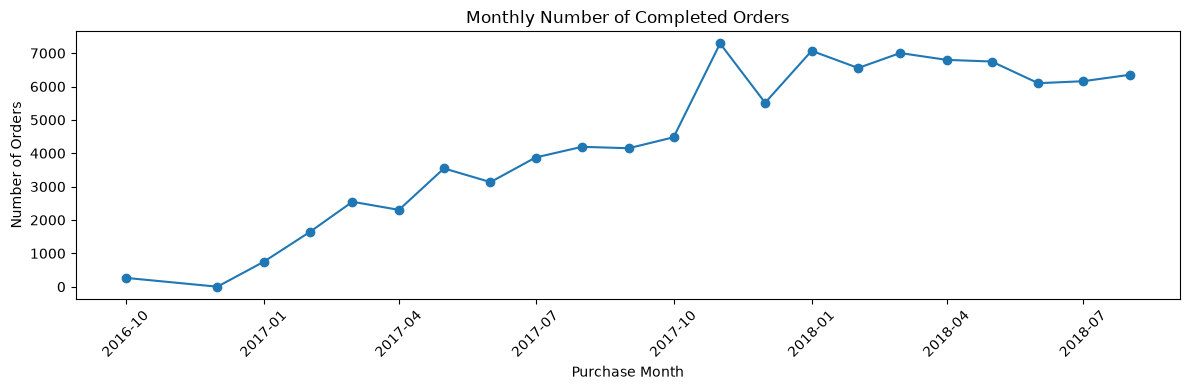

In [18]:
# Create a monthly variable from the purchase timestamp.
transactions["purchase_month"] = (
    transactions["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Aggregate completed orders by month.
monthly_transactions = (
    transactions.groupby("purchase_month", as_index=False)
    .agg(
        Number_of_Orders=("order_id", "nunique")
    )
)

# Display the monthly summary.
display(monthly_transactions.head())

# Create a line chart showing monthly order volume.
plt.figure(figsize=(12, 4))

plt.plot(
    monthly_transactions["purchase_month"],
    monthly_transactions["Number_of_Orders"],
    marker="o"
)

plt.title("Monthly Number of Completed Orders")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Monthly completed orders increased substantially during the observation period and became **relatively stable from late 2017 onward.**

Based on this pattern, **May 31, 2018** is selected as the calibration cutoff, leaving approximately 90 days from June to August 2018 as the holdout period.

In [19]:
# Define the final date of the calibration period.
calibration_end = pd.Timestamp("2018-05-31 23:59:59")

# Create the calibration dataset using transactions observed up to the cutoff date.
calibration_transactions = transactions[
    transactions["order_purchase_timestamp"] <= calibration_end
].copy()

# Create the holdout dataset using transactions observed after the cutoff date.
holdout_transactions = transactions[
    transactions["order_purchase_timestamp"] > calibration_end
].copy()

# Create a summary of the temporal split.
split_summary = pd.DataFrame({
    "Period": [
        "Calibration",
        "Holdout"
    ],
    "Start Date": [
        calibration_transactions["order_purchase_timestamp"].min(),
        holdout_transactions["order_purchase_timestamp"].min()
    ],
    "End Date": [
        calibration_transactions["order_purchase_timestamp"].max(),
        holdout_transactions["order_purchase_timestamp"].max()
    ],
    "Number of Orders": [
        calibration_transactions["order_id"].nunique(),
        holdout_transactions["order_id"].nunique()
    ],
    "Number of Customers": [
        calibration_transactions["customer_unique_id"].nunique(),
        holdout_transactions["customer_unique_id"].nunique()
    ]
})

# Display the temporal split summary.
display(split_summary)

,Period,Start Date,End Date,Number of Orders,Number of Customers
0,Calibration,2016-10-03 09:44:50,2018-05-31 23:51:24,77868,75386
1,Holdout,2018-06-01 00:39:55,2018-08-29 15:00:37,18609,18390


This chronological split **prevents data leakage**, because future customer behaviour is not used when constructing calibration features.


## Probabilistic Modeling with BTYD

The probabilistic approach follows the **Buy Till You Die framework.**

- The BG/NBD model estimates **the expected number of future purchases and the probability that each customer is still active**;
- The Gamma-Gamma model estimates **the expected average monetary value per transaction.**

The two models are then combined to calculate the predicted 90-day Customer Lifetime Value.

#### BTYD Customer Table

The cleaned transactions are summarized at customer level using the calibration and holdout periods. The BTYD variables are:

- `frequency_cal`: number of repeat purchases during calibration;
- `recency_cal`: time between the first and last calibration purchase;
- `T_cal`: time between the first purchase and the end of calibration;
- `monetary_value_cal`: average value of repeat purchases;
- `frequency_holdout`: actual repeat purchases during holdout;
- `monetary_value_holdout`: actual average transaction value during holdout.

In [20]:
# Import the utility used to create calibration and holdout summaries.
from lifetimes.utils import calibration_and_holdout_data

# Define the calibration and observation end dates.
calibration_end_date = pd.Timestamp("2018-05-31")
observation_end_date = transactions["order_purchase_timestamp"].max().normalize()

# Create the customer-level BTYD table.
btyd_data = calibration_and_holdout_data(
    transactions=transactions,
    customer_id_col="customer_unique_id",
    datetime_col="order_purchase_timestamp",
    monetary_value_col="order_payment_value",
    calibration_period_end=calibration_end_date,
    observation_period_end=observation_end_date,
    freq="D"
).reset_index()

# Display the first rows.
display(btyd_data.head())

# Display the number of customers included.
print("Number of calibration customers:", len(btyd_data))

,customer_unique_id,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
0,0000366f3b9a7992bf8c76cfdf3221e2,0.00,0.00,21.00,0.00,0.00,0.00,90.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.00,0.00,24.00,0.00,0.00,0.00,90.00
2,0000f46a3911fa3c0805444483337064,0.00,0.00,447.00,0.00,0.00,0.00,90.00
3,0000f6ccb0745a6a4b88665a16c9f078,0.00,0.00,231.00,0.00,0.00,0.00,90.00
4,0004aac84e0df4da2b147fca70cf8255,0.00,0.00,198.00,0.00,0.00,0.00,90.00


Number of calibration customers: 75259


The resulting table contains one row per customer observed during calibration and includes both calibration features and actual holdout outcomes.

### BG/NBD Model

The BG/NBD model estimates customer purchasing behaviour in a **non-contractual setting**, where customer churn is not directly observed. The model uses:

- `frequency_cal` to measure repeat purchases;
- `recency_cal` to measure the time between the first and last purchase;
- `T_cal` to measure the total customer observation period.

The fitted model is used to estimate the expected number of purchases during the next 90 days and the probability that each customer is still active.

In [21]:
# Import the BG/NBD model.
from lifetimes import BetaGeoFitter

# Initialize and fit the model.
bgf = BetaGeoFitter(penalizer_coef=0.001)

bgf.fit(
    frequency=btyd_data["frequency_cal"],
    recency=btyd_data["recency_cal"],
    T=btyd_data["T_cal"]
)

# Predict future purchases over the 90-day holdout period.
btyd_data["predicted_purchases_90d"] = bgf.predict(
    90,
    btyd_data["frequency_cal"],
    btyd_data["recency_cal"],
    btyd_data["T_cal"]
)

# Estimate the probability that each customer is still active.
btyd_data["probability_alive"] = bgf.conditional_probability_alive(
    btyd_data["frequency_cal"],
    btyd_data["recency_cal"],
    btyd_data["T_cal"]
)

# Display the main model outputs.
display(
    btyd_data[
        [
            "customer_unique_id",
            "frequency_cal",
            "recency_cal",
            "T_cal",
            "predicted_purchases_90d",
            "probability_alive"
        ]
    ].head()
)

,customer_unique_id,frequency_cal,recency_cal,T_cal,predicted_purchases_90d,probability_alive
0,0000366f3b9a7992bf8c76cfdf3221e2,0.00,0.00,21.00,0.01,1.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.00,0.00,24.00,0.01,1.00
2,0000f46a3911fa3c0805444483337064,0.00,0.00,447.00,0.00,1.00
3,0000f6ccb0745a6a4b88665a16c9f078,0.00,0.00,231.00,0.00,1.00
4,0004aac84e0df4da2b147fca70cf8255,0.00,0.00,198.00,0.01,1.00


The BG/NBD model produces customer-level estimates of future purchase activity and probability of being alive. Customers with no repeat purchases generally receive **very low expected purchase values**, reflecting the weak retention observed in the dataset.

### Gamma-Gamma Model

The Gamma-Gamma model estimates **the expected average monetary value of future transactions.**

It is fitted only on customers with at least one repeat purchase and a positive monetary value. Before fitting, the correlation between purchase frequency and monetary value is checked because the model assumes approximate independence between the two variables.

In [22]:
# Select customers eligible for Gamma-Gamma modeling.
gamma_gamma_data = btyd_data[
    (btyd_data["frequency_cal"] > 0)
    & (btyd_data["monetary_value_cal"] > 0)
].copy()

# Check the correlation assumption.
frequency_monetary_correlation = gamma_gamma_data[
    "frequency_cal"
].corr(
    gamma_gamma_data["monetary_value_cal"]
)

print(
    "Correlation between frequency and monetary value:",
    round(frequency_monetary_correlation, 3)
)

print(
    "Customers eligible for Gamma-Gamma:",
    len(gamma_gamma_data)
)

Correlation between frequency and monetary value: 0.005
Customers eligible for Gamma-Gamma: 1500


**The correlation between purchase frequency and monetary value is 0.005**, which is extremely close to zero. Therefore, the independence assumption required by the Gamma-Gamma model is reasonably satisfied. A total of **1,500 customers have at least one repeat purchase** and a positive monetary value, making them eligible for Gamma-Gamma estimation.

In [23]:
# Import the Gamma-Gamma model.
from lifetimes import GammaGammaFitter

# Initialize and fit the model.
ggf = GammaGammaFitter(penalizer_coef=0.001)

ggf.fit(
    frequency=gamma_gamma_data["frequency_cal"],
    monetary_value=gamma_gamma_data["monetary_value_cal"]
)

# Estimate the expected average transaction value.
gamma_gamma_data["expected_average_value"] = (
    ggf.conditional_expected_average_profit(
        gamma_gamma_data["frequency_cal"],
        gamma_gamma_data["monetary_value_cal"]
    )
)

# Display the first estimates.
display(
    gamma_gamma_data[
        [
            "customer_unique_id",
            "frequency_cal",
            "monetary_value_cal",
            "expected_average_value"
        ]
    ].head()
)

,customer_unique_id,frequency_cal,monetary_value_cal,expected_average_value
81,004288347e5e88a27ded2bb23747066c,1.00,103.28,109.30
322,011575986092c30523ecb71ff10cb473,1.00,80.32,87.08
335,011b4adcd54683b480c4d841250a987f,1.00,149.88,154.42
344,012452d40dafae4df401bced74cdb490,1.00,340.07,338.55
378,013f4353d26bb05dc6652f1269458d8d,1.00,164.04,168.13


The Gamma-Gamma model estimates each eligible customer's expected average future transaction value. The predicted values are generally close to the observed calibration monetary values, but they are adjusted toward the population average to reduce the influence of unusually high or low spending histories.

### 90-Day Predicted CLTV

The BG/NBD and Gamma-Gamma models are combined to estimate each eligible customer's discounted CLTV over the next three months.

In [24]:
# Calculate the discounted 3-month CLTV for Gamma-Gamma eligible customers.
gamma_gamma_data["predicted_cltv_90d"] = (
    ggf.customer_lifetime_value(
        transaction_prediction_model=bgf,
        frequency=gamma_gamma_data["frequency_cal"],
        recency=gamma_gamma_data["recency_cal"],
        T=gamma_gamma_data["T_cal"],
        monetary_value=gamma_gamma_data["monetary_value_cal"],
        time=3,
        freq="D",
        discount_rate=0.01
    )
)

# Display the highest predicted CLTV customers.
display(
    gamma_gamma_data[
        [
            "customer_unique_id",
            "predicted_purchases_90d",
            "probability_alive",
            "expected_average_value",
            "predicted_cltv_90d"
        ]
    ]
    .sort_values(
        "predicted_cltv_90d",
        ascending=False
    )
    .head(10)
)

,customer_unique_id,predicted_purchases_90d,probability_alive,expected_average_value,predicted_cltv_90d
12204,297ec5afd18366f5ba27520cc4954151,0.68,0.73,694.55,460.49
16959,397b44d5bb99eabf54ea9c2b41ebb905,0.59,0.75,572.75,329.66
2651,08e5b38d7948d37fbb2a59fc5e175ab1,0.72,0.72,349.77,247.94
18381,3e43e6105506432c953e165fb2acf44c,0.93,0.72,215.30,197.01
8789,1da09dd64e235e7c2f29a4faff33535c,0.24,0.62,836.06,193.47
59614,ca77025e7201e3b30c44b472ff346268,1.24,0.89,148.83,180.29
47139,a029899dd8534557a81c369475ff80c8,0.86,0.66,195.44,164.94
979,0341bbd5c969923a0f801b9e2d10a7b8,0.15,0.16,"1,050.62",157.74
27925,5e8f38a9a1c023f3db718edcf926a2db,0.74,0.77,212.13,153.93
62327,d387ea85dc301a91740e31360d355686,0.63,0.77,229.93,142.44


The table shows the customers with the highest predicted 90-day CLTV. Customer value depends on both expected purchase activity and expected transaction value. Some customers achieve a high predicted CLTV because they are likely to purchase again, while others have fewer expected purchases but a very high expected monetary value. These customers represent **the most economically valuable segment for retention and loyalty initiatives.**

In [25]:
# Calculate the total predicted 90-day value
# of customers eligible for Gamma-Gamma estimation.
total_predicted_cltv_90d = (
    gamma_gamma_data["predicted_cltv_90d"].sum()
)

print(
    "Estimated total 90-day customer value:",
    round(total_predicted_cltv_90d, 2)
)

Estimated total 90-day customer value: 13495.43


The estimated total 90-day customer value is obtained by summing the individual CLTV predictions generated by the BTYD framework. The value **$13.5K** refers to **customers eligible for Gamma-Gamma estimation, namely customers with repeat purchase history and positive monetary value.**

### BTYD Model Evaluation

The probabilistic predictions are evaluated against the actual revenue generated during the 90-day holdout period. The comparison is performed only for customers eligible for Gamma-Gamma modeling, since the predicted CLTV is available for customers with repeat purchase history and positive monetary value.

In [26]:
# Import the regression evaluation metrics.
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate the actual holdout revenue for each customer.
holdout_revenue_by_customer = (
    holdout_transactions
    .groupby("customer_unique_id", as_index=False)
    .agg(
        actual_holdout_revenue=("order_payment_value", "sum")
    )
)

# Merge actual holdout revenue with the BTYD customer predictions.
btyd_evaluation = gamma_gamma_data.merge(
    holdout_revenue_by_customer,
    on="customer_unique_id",
    how="left"
)

# Assign zero revenue to customers who did not purchase during holdout.
btyd_evaluation["actual_holdout_revenue"] = (
    btyd_evaluation["actual_holdout_revenue"]
    .fillna(0)
)

# Calculate the BTYD evaluation metrics.
btyd_mae = mean_absolute_error(
    btyd_evaluation["actual_holdout_revenue"],
    btyd_evaluation["predicted_cltv_90d"]
)

btyd_mse = mean_squared_error(
    btyd_evaluation["actual_holdout_revenue"],
    btyd_evaluation["predicted_cltv_90d"]
)

btyd_rmse = np.sqrt(btyd_mse)

# Create a summary table of BTYD performance.
btyd_metrics = pd.DataFrame({
    "Model": ["BTYD"],
    "MAE": [btyd_mae],
    "MSE": [btyd_mse],
    "RMSE": [btyd_rmse]
})

# Display the final BTYD evaluation results.
display(btyd_metrics)

,Model,MAE,MSE,RMSE
0,BTYD,11.83,"2,345.56",48.43


The BTYD model achieves an **MAE of 11.83 and an RMSE of 48.43** when predicting customer revenue over the 90-day holdout period.

The difference between MAE and RMSE indicates that most prediction errors are moderate, while a **smaller number of customers generate substantially larger errors**. These results provide the probabilistic benchmark that will later be compared with the machine learning approach.

#### BG/NBD Purchase Validation

Actual and predicted holdout purchases are compared across **the most representative calibration-frequency groups**.The visualization is limited to low-frequency groups because higher frequencies contain very few customers and produce unstable averages.


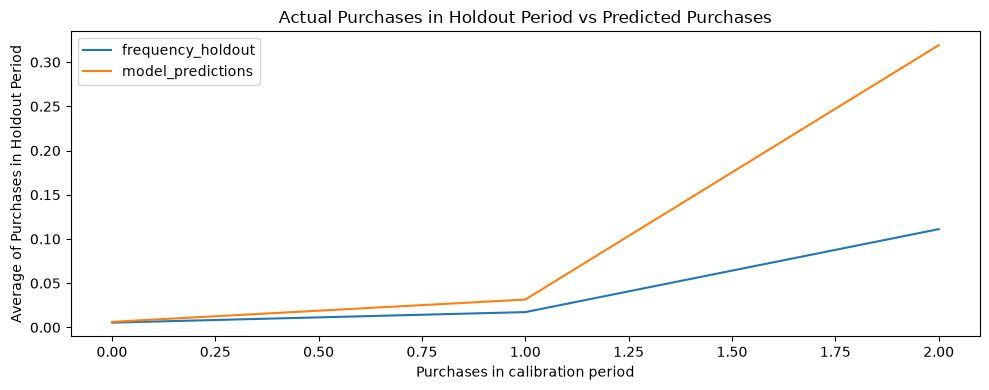

In [27]:
# Import the diagnostic plot for calibration and holdout purchases.
from lifetimes.plotting import (
    plot_calibration_purchases_vs_holdout_purchases
)

# Compare actual and predicted holdout purchases
# for the most representative calibration-frequency groups.
plot_calibration_purchases_vs_holdout_purchases(
    bgf,
    btyd_data,
    n=3,
    figsize=(10, 4)
)

# Improve the plot layout.
plt.tight_layout()

# Display the final chart.
plt.show()

The BG/NBD model provides reasonably close estimates for customers with zero or one repeat purchase during calibration. However, **it overestimates future purchases for customers with higher calibration frequency**. Therefore, the model represents the majority of low-frequency customers more accurately than the smaller repeat-customer groups.

## Machine Learning Regression

The machine learning approach uses customer behaviour observed during the calibration period to predict **the total revenue generated during the holdout period.**

Customer-level features are created exclusively from calibration transactions, while **holdout revenue is used as the target variable**. This separation prevents data leakage.

### Customer-Level Feature Engineering

The calibration transactions are **aggregated at customer level.** The model uses behavioural and monetary features such as Recency, Frequency, Monetary Value, customer tenure, average order value, number of purchased items and payment characteristics.

In [28]:
# Define the reference date as the end of the calibration period.
calibration_reference_date = pd.Timestamp("2018-05-31 23:59:59")

# Aggregate calibration transactions at customer level.
ml_features = (
    calibration_transactions
    .groupby("customer_unique_id")
    .agg(
        # Store the first and last observed purchase dates.
        first_purchase_date=("order_purchase_timestamp", "min"),
        last_purchase_date=("order_purchase_timestamp", "max"),

        # Calculate purchasing behaviour.
        Frequency=("order_id", "nunique"),
        Monetary_Value=("order_payment_value", "sum"),
        Average_Order_Value=("order_payment_value", "mean"),

        # Calculate product and payment characteristics.
        Total_Items=("number_of_items", "sum"),
        Average_Items_Per_Order=("number_of_items", "mean"),
        Maximum_Installments=("maximum_installments", "max"),
        Number_of_Payment_Methods=("number_of_payment_methods", "max")
    )
    .reset_index()
)

# Calculate Recency as the number of days since the last purchase.
ml_features["Recency"] = (
    calibration_reference_date
    - ml_features["last_purchase_date"]
).dt.days

# Calculate customer tenure T as the number of days
# between the first purchase and the calibration cutoff.
ml_features["T"] = (
    calibration_reference_date
    - ml_features["first_purchase_date"]
).dt.days

# Remove the original date columns because the regression model
# requires numerical input features.
ml_features = ml_features.drop(
    columns=[
        "first_purchase_date",
        "last_purchase_date"
    ]
)

# Display the first customer-level feature records.
display(ml_features.head())

# Display the shape of the machine learning feature table.
print("ML feature table shape:", ml_features.shape)

,customer_unique_id,Frequency,Monetary_Value,Average_Order_Value,Total_Items,Average_Items_Per_Order,Maximum_Installments,Number_of_Payment_Methods,Recency,T
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,1,1.00,8,1,21,21
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1,1.00,1,1,24,24
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,1,1.00,8,1,447,447
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,1,1.00,4,1,231,231
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,1,1.00,6,1,198,198


ML feature table shape: (75386, 10)


The machine learning feature table contains 75,386 customers observed during the calibration period. Each row summarizes the customer's historical purchasing, spending and payment behaviour. For one-time customers, Recency and `T` are equal because the first and last purchase dates coincide.

### Holdout Revenue Target

The regression target is **the total revenue generated by each calibration customer during the holdout period.** Customers who did not purchase during the holdout period are assigned a target value of zero.

In [29]:
# Aggregate actual customer revenue during the holdout period.
holdout_revenue = (
    holdout_transactions
    .groupby("customer_unique_id", as_index=False)
    .agg(
        Holdout_Revenue=("order_payment_value", "sum"),
        Holdout_Orders=("order_id", "nunique")
    )
)

# Merge the holdout outcomes with the calibration customer features.
ml_dataset = ml_features.merge(
    holdout_revenue,
    on="customer_unique_id",
    how="left"
)

# Assign zero revenue and zero orders to customers
# who did not purchase during the holdout period.
ml_dataset[
    [
        "Holdout_Revenue",
        "Holdout_Orders"
    ]
] = ml_dataset[
    [
        "Holdout_Revenue",
        "Holdout_Orders"
    ]
].fillna(0)

# Display the first rows of the final machine learning dataset.
display(ml_dataset.head())

# Display the dimensions of the final dataset.
print("ML dataset shape:", ml_dataset.shape)

# Calculate the number of active and inactive customers in the holdout period.
holdout_target_summary = pd.DataFrame({
    "Customer Group": [
        "Customers with Holdout Purchases",
        "Customers without Holdout Purchases"
    ],
    "Number of Customers": [
        (ml_dataset["Holdout_Orders"] > 0).sum(),
        (ml_dataset["Holdout_Orders"] == 0).sum()
    ]
})

# Calculate the percentage represented by each customer group.
holdout_target_summary["Percentage"] = (
    holdout_target_summary["Number of Customers"]
    / len(ml_dataset)
    * 100
)

# Display the holdout target summary.
display(holdout_target_summary)

,customer_unique_id,Frequency,Monetary_Value,Average_Order_Value,Total_Items,Average_Items_Per_Order,Maximum_Installments,Number_of_Payment_Methods,Recency,T,Holdout_Revenue,Holdout_Orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,1,1.00,8,1,21,21,0.00,0.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1,1.00,1,1,24,24,0.00,0.00
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,1,1.00,8,1,447,447,0.00,0.00
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,1,1.00,4,1,231,231,0.00,0.00
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,1,1.00,6,1,198,198,0.00,0.00


ML dataset shape: (75386, 12)


,Customer Group,Number of Customers,Percentage
0,Customers with Holdout Purchases,419,0.56
1,Customers without Holdout Purchases,74967,99.44


Only 419 calibration customers generated revenue during the holdout period, while 99.44% made no additional purchase. This confirms the **extreme sparsity of future customer revenue** and highlights the difficulty of the regression task.

### Model Training and Tuning

**Random Forest and XGBoost regressors** are trained using calibration-period customer features. **A grid search with 3-fold cross-validation** is applied to the training set to identify the best hyperparameter configuration. The final models are then evaluated on the separate test set.

In [30]:
# Import the required machine learning tools.
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# Define the model inputs using only calibration-period features.
X = ml_dataset.drop(
    columns=[
        "customer_unique_id",
        "Holdout_Revenue",
        "Holdout_Orders"
    ]
)

# Define holdout revenue as the regression target.
y = ml_dataset["Holdout_Revenue"]

# Create an indicator only to preserve the proportion of purchasing customers.
purchase_indicator = (y > 0).astype(int)

# Split the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=purchase_indicator
)

# Apply a logarithmic transformation to the training target
# because holdout revenue is strongly right-skewed.
y_train_log = np.log1p(y_train)

# Define the Random Forest model and parameter grid.
rf_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_parameters = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [2, 5]
}

# Tune the Random Forest using cross-validation on the training set.
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_parameters,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train_log)

# Define the XGBoost model and parameter grid.
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_parameters = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1]
}

# Tune XGBoost using cross-validation on the training set.
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_parameters,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train_log)

# Generate predictions and return them to the original monetary scale.
rf_predictions = np.expm1(rf_grid.predict(X_test))
xgb_predictions = np.expm1(xgb_grid.predict(X_test))

# Ensure that predicted revenue cannot be negative.
rf_predictions = np.clip(rf_predictions, 0, None)
xgb_predictions = np.clip(xgb_predictions, 0, None)

# Evaluate both models.
model_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, rf_predictions),
        mean_absolute_error(y_test, xgb_predictions)
    ],
    "MSE": [
        mean_squared_error(y_test, rf_predictions),
        mean_squared_error(y_test, xgb_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_predictions)),
        np.sqrt(mean_squared_error(y_test, xgb_predictions))
    ]
})

# Display the selected hyperparameters and final performance.
print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best XGBoost parameters:", xgb_grid.best_params_)

display(model_results)

Best Random Forest parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}
Best XGBoost parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}


,Model,MAE,MSE,RMSE
0,Random Forest,0.96,404.78,20.12
1,XGBoost,0.96,404.83,20.12


**Random Forest and XGBoost achieve almost identical performance.**

The low MAE is mainly driven by the large proportion of customers with zero holdout revenue. However, the higher MSE and RMSE indicate that both models make larger errors on the small number of customers who generate substantial future revenue.

## Final Model Comparison

The probabilistic **BTYD model, Random Forest and XGBoost are evaluated on the same customer subset and against the same actual holdout revenue.**

For BTYD, the expected 90-day revenue is calculated by multiplying the expected number of purchases by the expected average transaction value. This non-discounted prediction is directly comparable with the revenue observed during the holdout period. Using the same customers and target ensures a **fair comparison across the three models.**

In [31]:
# Calculate the non-discounted 90-day revenue predicted by BTYD.
# This value can be directly compared with actual holdout revenue.
gamma_gamma_data["btyd_predicted_revenue_90d"] = (
    gamma_gamma_data["predicted_purchases_90d"]
    * gamma_gamma_data["expected_average_value"]
)

# Create a table containing Random Forest and XGBoost predictions
# for customers included in the machine learning test set.
ml_test_predictions = pd.DataFrame({
    "customer_unique_id": ml_dataset.loc[
        X_test.index,
        "customer_unique_id"
    ].values,
    "actual_holdout_revenue": y_test.values,
    "rf_predicted_revenue": rf_predictions,
    "xgb_predicted_revenue": xgb_predictions
})

# Select the BTYD predictions required for the final comparison.
btyd_predictions = gamma_gamma_data[
    [
        "customer_unique_id",
        "btyd_predicted_revenue_90d"
    ]
].copy()

# Merge the probabilistic and machine learning predictions.
# The inner join retains only customers evaluated by all three models.
common_evaluation = ml_test_predictions.merge(
    btyd_predictions,
    on="customer_unique_id",
    how="inner"
)

# Display the number of customers included in the common evaluation.
print(
    "Customers included in the common evaluation:",
    len(common_evaluation)
)

# Display the first comparison records.
display(common_evaluation.head())

Customers included in the common evaluation: 296


,customer_unique_id,actual_holdout_revenue,rf_predicted_revenue,xgb_predicted_revenue,btyd_predicted_revenue_90d
0,51d91326ffc0688da14a001de38c264b,0.00,0.31,0.05,2.31
1,5a819fa976c2a1e65fa35e5c890d4dcb,0.00,0.05,0.03,6.83
2,21421ba1bd92005a3b48e6a745e9b8bb,0.00,0.04,0.04,8.12
3,142575266950512b56af193f3962270a,0.00,0.04,0.04,1.50
4,21bde4e982c4681021edabb899bcebfe,0.00,0.03,0.03,0.88


In [32]:
# Calculate BTYD evaluation metrics.
btyd_final_mae = mean_absolute_error(
    common_evaluation["actual_holdout_revenue"],
    common_evaluation["btyd_predicted_revenue_90d"]
)

btyd_final_mse = mean_squared_error(
    common_evaluation["actual_holdout_revenue"],
    common_evaluation["btyd_predicted_revenue_90d"]
)

btyd_final_rmse = np.sqrt(btyd_final_mse)

# Calculate Random Forest evaluation metrics.
rf_final_mae = mean_absolute_error(
    common_evaluation["actual_holdout_revenue"],
    common_evaluation["rf_predicted_revenue"]
)

rf_final_mse = mean_squared_error(
    common_evaluation["actual_holdout_revenue"],
    common_evaluation["rf_predicted_revenue"]
)

rf_final_rmse = np.sqrt(rf_final_mse)

# Calculate XGBoost evaluation metrics.
xgb_final_mae = mean_absolute_error(
    common_evaluation["actual_holdout_revenue"],
    common_evaluation["xgb_predicted_revenue"]
)

xgb_final_mse = mean_squared_error(
    common_evaluation["actual_holdout_revenue"],
    common_evaluation["xgb_predicted_revenue"]
)

xgb_final_rmse = np.sqrt(xgb_final_mse)

# Create the final model-comparison table.
final_model_comparison = pd.DataFrame({
    "Model": [
        "BTYD",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        btyd_final_mae,
        rf_final_mae,
        xgb_final_mae
    ],
    "MSE": [
        btyd_final_mse,
        rf_final_mse,
        xgb_final_mse
    ],
    "RMSE": [
        btyd_final_rmse,
        rf_final_rmse,
        xgb_final_rmse
    ]
})

# Round the results for clearer presentation.
final_model_comparison[
    ["MAE", "MSE", "RMSE"]
] = final_model_comparison[
    ["MAE", "MSE", "RMSE"]
].round(2)

# Display the final comparison.
display(final_model_comparison)

# Identify the model achieving the lowest value for each metric.
best_mae_model = final_model_comparison.loc[
    final_model_comparison["MAE"].idxmin(),
    "Model"
]

best_mse_model = final_model_comparison.loc[
    final_model_comparison["MSE"].idxmin(),
    "Model"
]

best_rmse_model = final_model_comparison.loc[
    final_model_comparison["RMSE"].idxmin(),
    "Model"
]

print("Lowest MAE:", best_mae_model)
print("Lowest MSE:", best_mse_model)
print("Lowest RMSE:", best_rmse_model)

,Model,MAE,MSE,RMSE
0,BTYD,11.75,"1,318.29",36.31
1,Random Forest,5.78,"1,556.06",39.45
2,XGBoost,5.71,"1,558.94",39.48


Lowest MAE: XGBoost
Lowest MSE: BTYD
Lowest RMSE: BTYD


The results show a trade-off between average prediction accuracy and the ability to control large errors.

**1. BTYD achieves the lowest MSE and RMSE, with an RMSE of 36.31 compared with 39.45 for Random Forest and 39.48 for XGBoost.**

RMSE gives greater importance to large prediction errors. In the Olist dataset, this is especially relevant because customer spending is strongly right-skewed: most customers generate little or no revenue during the holdout period, while a small number generate much higher amounts.

**What this means for you:** suppose a high-value Olist customer generates 300 monetary units during the holdout period. A machine learning model might predict only 50, producing a very large error. Even if this happens for only a few customers, these mistakes can strongly distort the total revenue forecast. BTYD makes smaller errors on these extreme cases, which is why it is more suitable for macro-level financial planning and customer-base valuation.


**2. XGBoost achieves the lowest MAE, equal to 5.71, compared with 5.78 for Random Forest and 11.75 for BTYD.**

MAE measures the average absolute error across all customers. In this dataset, most calibration customers generate zero holdout revenue, while only a very small share purchase again.

**What this means for you:** for the majority of Olist customers, who either generate no future revenue or only a small amount, XGBoost produces predictions that are closer to the actual outcome. For example, if a customer generates no revenue during holdout, XGBoost is more likely to predict a value close to zero than BTYD. This makes it more useful for individual customer ranking, campaign targeting and short-term operational decisions.


**Business Interpretation**

- BTYD should be selected when the objective is to **forecast the overall value of the customer base**, because it better controls large errors on the few high-value customers who can materially affect total revenue.
- XGBoost should be selected when the objective is to **predict future revenue for individual customers**, because it is more accurate for the large majority of low-value or inactive customers in the Olist database.


### Win-Back Customer Prioritization

The predicted 90-day CLTV and probability alive are combined to **identify customers who should be prioritized for a win-back campaign.** Priority is assigned to customers with high predicted value but low probability of remaining active, since they represent economically important customers at risk of inactivity.

In [33]:
# Define high-value customers as those above the 75th percentile of predicted CLTV.
high_cltv_threshold = gamma_gamma_data[
    "predicted_cltv_90d"
].quantile(0.75)

# Define at-risk customers as those below the 25th percentile
# of probability alive.
low_alive_threshold = gamma_gamma_data[
    "probability_alive"
].quantile(0.25)

# Select customers with high predicted value
# and low probability of remaining active.
win_back_customers = gamma_gamma_data[
    (gamma_gamma_data["predicted_cltv_90d"] >= high_cltv_threshold)
    & (gamma_gamma_data["probability_alive"] <= low_alive_threshold)
].copy()

# Create the main indicators for the marketing slide.
win_back_kpis = pd.DataFrame({
    "Metric": [
        "Priority Win-Back Customers",
        "Share of Eligible Customers",
        "Total Predicted 90-Day CLTV",
        "Average Predicted CLTV",
        "Average Probability Alive"
    ],
    "Value": [
        len(win_back_customers),
        len(win_back_customers) / len(gamma_gamma_data) * 100,
        win_back_customers["predicted_cltv_90d"].sum(),
        win_back_customers["predicted_cltv_90d"].mean(),
        win_back_customers["probability_alive"].mean()
    ]
})

display(win_back_kpis)

,Metric,Value
0,Priority Win-Back Customers,10.00
1,Share of Eligible Customers,0.67
2,Total Predicted 90-Day CLTV,135.73
3,Average Predicted CLTV,13.57
4,Average Probability Alive,0.06


The win-back segment contains **10 high-value customers with a very low average probability alive of 0.06.** Although these customers are considered at risk of inactivity, their total predicted 90-day CLTV is limited to **R$135.73**. Therefore, the recommended strategy is a **highly targeted and low-cost campaign**, using personalized reminders or small time-limited incentives rather than expensive promotions.